In [1]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn as sns

In [4]:
experiment = "IHC_Exp12"
protein = "VCAM1"
synapse_type = "VGAT-GEPH"

In [5]:
vgat_geph_results_file = f"/Volumes/Intenso/image-analysis/synapse-counting/{experiment}_{protein}_{synapse_type}_output_data/metric_results.csv"
vgat_geph_results = pd.read_csv(vgat_geph_results_file)
vgat_geph_results

,Unnamed: 0,img_filename,local_peak_colocalized_spots,local_peak_colocalized_spots_rot,overlap_coeff,overlap_coeff_rot,overlap_um2,overlap_um2_rot,pearson_cor,pvalue,...,postsynapse_image_mfi,pre_puncta_density_per_100_um2,post_puncta_density_per_100_um2,pre_staining_area_um2,post_staining_area_um2,pre_mean_puncta_size_um2,post_mean_puncta_size_um2,gRNA,hippocampal_layer,Brain
0,0,CRISPR-Exp5_IHC-Exp12_Brain-7_section-3_LacZ-g...,18,2,0.045748,0.004232,0.386767,0.035780,0.151800,0.0,...,222.508094,3.582041,10.635907,4.642906,15.143541,0.071429,0.078464,LacZ-gRNA,CA3 SO,Brain-7
1,1,CRISPR-Exp4_IHC-Exp12_Brain-4-2_section-1_VCAM...,9,0,0.086973,0.008401,1.552179,0.149936,0.120392,0.0,...,238.897328,19.838997,7.825382,20.910968,14.916933,0.058086,0.105049,VCAM1-gRNA,CA3 SO,Brain-4-2
2,2,CRISPR-Exp5_IHC-Exp12_Brain-7_section-2_LacZ-g...,4,1,0.000000,0.003707,0.000000,0.018742,0.063671,0.0,...,218.734771,6.502782,3.196283,6.116709,4.051681,0.051837,0.069857,LacZ-gRNA,DG ML,Brain-7
3,3,CRISPR-Exp5_IHC-Exp12_Brain-7_section-3_LacZ-g...,10,2,0.051476,0.005267,0.366321,0.037484,0.119249,0.0,...,238.038362,5.786374,6.227241,4.772396,10.134314,0.045451,0.089684,LacZ-gRNA,DG ML,Brain-7
4,4,CRISPR-Exp4_IHC-Exp12_Brain-4_section-2_LacZ-g...,3,0,0.112493,0.005093,2.182592,0.098821,0.190412,0.0,...,190.210763,25.349830,8.376465,27.029381,13.927014,0.058760,0.091625,LacZ-gRNA,CA1 SO,Brain-4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,187,CRISPR-Exp5_IHC-Exp12_Brain-7_section-2_LacZ-g...,2,0,0.008607,0.003311,0.088599,0.034076,0.074103,0.0,...,225.462072,2.700308,33.891620,2.514836,42.130326,0.051323,0.068505,LacZ-gRNA,CA1 SR,Brain-7
188,188,CRISPR-Exp4_IHC-Exp12_Brain-4-2_section-3_VCAM...,33,7,0.029613,0.002300,0.175493,0.013631,0.129470,0.0,...,302.024953,5.896591,4.739316,5.803207,5.951439,0.054236,0.069203,VCAM1-gRNA,CA3 SO,Brain-4-2
189,189,CRISPR-Exp5_IHC-Exp12_Brain-5_section-1_LacZ-g...,13,4,0.125469,0.019103,2.383642,0.362913,0.147625,0.0,...,267.375240,29.427846,7.604949,28.683789,12.582701,0.053715,0.091179,LacZ-gRNA,CA1 SO,Brain-5
190,190,CRISPR-Exp4_IHC-Exp12_Brain-4_section-1_LacZ-g...,1,0,0.007974,0.000181,0.074968,0.001704,0.089269,0.0,...,199.702532,4.298449,12.068723,3.705806,23.231569,0.047510,0.106080,LacZ-gRNA,DG ML,Brain-4


In [6]:
# creating a new column with the sample_ID
vgat_geph_results["sample_ID"] = vgat_geph_results["gRNA"].str.cat(vgat_geph_results[["Brain"]], sep = "_")

In [7]:
# checking specific feature
vgat_geph_results[(vgat_geph_results["Brain"] == "Brain-4") & (vgat_geph_results["hippocampal_layer"] == "DG ML") & (vgat_geph_results["gRNA"] == "LacZ-gRNA")]

,Unnamed: 0,img_filename,local_peak_colocalized_spots,local_peak_colocalized_spots_rot,overlap_coeff,overlap_coeff_rot,overlap_um2,overlap_um2_rot,pearson_cor,pvalue,...,pre_puncta_density_per_100_um2,post_puncta_density_per_100_um2,pre_staining_area_um2,post_staining_area_um2,pre_mean_puncta_size_um2,post_mean_puncta_size_um2,gRNA,hippocampal_layer,Brain,sample_ID
52,52,CRISPR-Exp4_IHC-Exp12_Brain-4_section-2_LacZ-g...,0,0,0.003532,0.000000,0.010223,0.000000,0.110773,0.0,...,3.306500,2.865633,2.281413,3.523497,0.038024,0.067760,LacZ-gRNA,DG ML,Brain-4,LacZ-gRNA_Brain-4
72,72,CRISPR-Exp4_IHC-Exp12_Brain-4_section-3_LacZ-g...,5,1,0.084684,0.014470,1.754933,0.299872,0.163697,0.0,...,14.438381,14.934356,14.143399,29.757195,0.053982,0.109805,LacZ-gRNA,DG ML,Brain-4,LacZ-gRNA_Brain-4
190,190,CRISPR-Exp4_IHC-Exp12_Brain-4_section-1_LacZ-g...,1,0,0.007974,0.000181,0.074968,0.001704,0.089269,0.0,...,4.298449,12.068723,3.705806,23.231569,0.047510,0.106080,LacZ-gRNA,DG ML,Brain-4,LacZ-gRNA_Brain-4


In [8]:
df2_grouped_brain = vgat_geph_results.groupby(["sample_ID", "hippocampal_layer"], as_index=False)[["local_peak_colocalized_spots",
                                        "overlap_coeff",
                                        "overlap_um2",
                                        "pearson_cor",
                                        "presynapse_image_mfi",
                                        "postsynapse_image_mfi",
                                        "pre_puncta_density_per_100_um2",
                                        "post_puncta_density_per_100_um2",
                                        "pre_staining_area_um2",
                                        "post_staining_area_um2",
                                        "pre_mean_puncta_size_um2",
                                        "post_mean_puncta_size_um2"]].mean()

In [9]:
df2_grouped_brain

,sample_ID,hippocampal_layer,local_peak_colocalized_spots,overlap_coeff,overlap_um2,pearson_cor,presynapse_image_mfi,postsynapse_image_mfi,pre_puncta_density_per_100_um2,post_puncta_density_per_100_um2,pre_staining_area_um2,post_staining_area_um2,pre_mean_puncta_size_um2,post_mean_puncta_size_um2
0,LacZ-gRNA_Brain-4,CA1 SLM,0.333333,0.049281,1.114865,0.148076,55.723005,264.317032,10.470582,23.035280,8.901885,42.056494,0.046183,0.097837
1,LacZ-gRNA_Brain-4,CA1 SO,4.333333,0.122348,2.949878,0.173544,45.802540,198.832602,25.974391,11.076773,29.119966,19.658661,0.061605,0.096750
2,LacZ-gRNA_Brain-4,CA1 SR,1.666667,0.066775,1.200624,0.118364,44.883851,204.071658,14.585337,11.113512,13.824217,19.361628,0.049682,0.096221
3,LacZ-gRNA_Brain-4,CA3 SL,1.333333,0.081253,0.235127,0.157530,42.238027,224.685405,2.057377,1.800205,2.719863,4.028395,0.071444,0.122302
4,LacZ-gRNA_Brain-4,CA3 SO,3.666667,0.053390,0.492404,0.134086,49.725908,237.142986,7.347777,7.255929,8.408346,11.479195,0.063591,0.085640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,VCAM1-gRNA_Brain-7,CA3 SL,3.666667,0.032876,0.172086,0.104693,55.189727,249.581418,2.792155,4.629099,2.828339,8.118128,0.052450,0.084769
60,VCAM1-gRNA_Brain-7,CA3 SO,19.333333,0.047968,0.542950,0.149130,62.018243,260.785518,5.161813,9.001026,5.334657,15.544506,0.057081,0.086074
61,VCAM1-gRNA_Brain-7,CA3 SR,16.000000,0.057817,0.862700,0.127433,56.083731,296.054856,17.653033,7.788643,18.075813,9.937807,0.055996,0.070299
62,VCAM1-gRNA_Brain-7,DG Hilus,1.333333,0.040765,0.285106,0.087407,54.821152,220.119948,8.027446,5.437355,7.468406,8.353255,0.055008,0.081801


In [10]:
df_grouped_section = vgat_geph_results[["sample_ID",
                                        "hippocampal_layer",
                                        "img_filename",
                                        "local_peak_colocalized_spots",
                                        "overlap_coeff",
                                        "overlap_um2",
                                        "pearson_cor",
                                        "presynapse_image_mfi",
                                        "postsynapse_image_mfi",
                                        "pre_puncta_density_per_100_um2",
                                        "post_puncta_density_per_100_um2",
                                        "pre_staining_area_um2",
                                        "post_staining_area_um2",
                                        "pre_mean_puncta_size_um2",
                                        "post_mean_puncta_size_um2"]]
final_df = df_grouped_section.reset_index()

In [11]:
df_grouped_section

,sample_ID,hippocampal_layer,img_filename,local_peak_colocalized_spots,overlap_coeff,overlap_um2,pearson_cor,presynapse_image_mfi,postsynapse_image_mfi,pre_puncta_density_per_100_um2,post_puncta_density_per_100_um2,pre_staining_area_um2,post_staining_area_um2,pre_mean_puncta_size_um2,post_mean_puncta_size_um2
0,LacZ-gRNA_Brain-7,CA3 SO,CRISPR-Exp5_IHC-Exp12_Brain-7_section-3_LacZ-g...,18,0.045748,0.386767,0.151800,78.445864,222.508094,3.582041,10.635907,4.642906,15.143541,0.071429,0.078464
1,VCAM1-gRNA_Brain-4-2,CA3 SO,CRISPR-Exp4_IHC-Exp12_Brain-4-2_section-1_VCAM...,9,0.086973,1.552179,0.120392,33.496182,238.897328,19.838997,7.825382,20.910968,14.916933,0.058086,0.105049
2,LacZ-gRNA_Brain-7,DG ML,CRISPR-Exp5_IHC-Exp12_Brain-7_section-2_LacZ-g...,4,0.000000,0.000000,0.063671,66.349709,218.734771,6.502782,3.196283,6.116709,4.051681,0.051837,0.069857
3,LacZ-gRNA_Brain-7,DG ML,CRISPR-Exp5_IHC-Exp12_Brain-7_section-3_LacZ-g...,10,0.051476,0.366321,0.119249,62.805478,238.038362,5.786374,6.227241,4.772396,10.134314,0.045451,0.089684
4,LacZ-gRNA_Brain-4,CA1 SO,CRISPR-Exp4_IHC-Exp12_Brain-4_section-2_LacZ-g...,3,0.112493,2.182592,0.190412,44.222670,190.210763,25.349830,8.376465,27.029381,13.927014,0.058760,0.091625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,LacZ-gRNA_Brain-7,CA1 SR,CRISPR-Exp5_IHC-Exp12_Brain-7_section-2_LacZ-g...,2,0.008607,0.088599,0.074103,58.937906,225.462072,2.700308,33.891620,2.514836,42.130326,0.051323,0.068505
188,VCAM1-gRNA_Brain-4-2,CA3 SO,CRISPR-Exp4_IHC-Exp12_Brain-4-2_section-3_VCAM...,33,0.029613,0.175493,0.129470,68.768158,302.024953,5.896591,4.739316,5.803207,5.951439,0.054236,0.069203
189,LacZ-gRNA_Brain-5,CA1 SO,CRISPR-Exp5_IHC-Exp12_Brain-5_section-1_LacZ-g...,13,0.125469,2.383642,0.147625,64.086791,267.375240,29.427846,7.604949,28.683789,12.582701,0.053715,0.091179
190,LacZ-gRNA_Brain-4,DG ML,CRISPR-Exp4_IHC-Exp12_Brain-4_section-1_LacZ-g...,1,0.007974,0.074968,0.089269,47.374979,199.702532,4.298449,12.068723,3.705806,23.231569,0.047510,0.106080


In [12]:
# to long format
df_melted = df2_grouped_brain.melt(id_vars=['sample_ID', 'hippocampal_layer'], var_name='metric', value_name='value')

# create new column based on hippocampal layer and metric
df_melted['synapse_hippocampal_layer_metric'] = synapse_type + "_" + df_melted['hippocampal_layer'] + '_' + df_melted['metric']

# pivot the dataframe back
df_pivot = df_melted.pivot(index='sample_ID', columns='synapse_hippocampal_layer_metric', values='value')

vgat_final_df = df_pivot.reset_index()
vgat_final_df.head(10)

synapse_hippocampal_layer_metric,sample_ID,VGAT-GEPH_CA1 SLM_local_peak_colocalized_spots,VGAT-GEPH_CA1 SLM_overlap_coeff,VGAT-GEPH_CA1 SLM_overlap_um2,VGAT-GEPH_CA1 SLM_pearson_cor,VGAT-GEPH_CA1 SLM_post_mean_puncta_size_um2,VGAT-GEPH_CA1 SLM_post_puncta_density_per_100_um2,VGAT-GEPH_CA1 SLM_post_staining_area_um2,VGAT-GEPH_CA1 SLM_postsynapse_image_mfi,VGAT-GEPH_CA1 SLM_pre_mean_puncta_size_um2,...,VGAT-GEPH_DG ML_overlap_um2,VGAT-GEPH_DG ML_pearson_cor,VGAT-GEPH_DG ML_post_mean_puncta_size_um2,VGAT-GEPH_DG ML_post_puncta_density_per_100_um2,VGAT-GEPH_DG ML_post_staining_area_um2,VGAT-GEPH_DG ML_postsynapse_image_mfi,VGAT-GEPH_DG ML_pre_mean_puncta_size_um2,VGAT-GEPH_DG ML_pre_puncta_density_per_100_um2,VGAT-GEPH_DG ML_pre_staining_area_um2,VGAT-GEPH_DG ML_presynapse_image_mfi
0,LacZ-gRNA_Brain-4,0.333333,0.049281,1.114865,0.148076,0.097837,23.035280,42.056494,264.317032,0.046183,...,0.613375,0.121246,0.094548,9.956237,18.837420,202.950817,0.046505,7.347777,6.710206,49.785690
1,LacZ-gRNA_Brain-4-2,3.000000,0.037878,0.663353,0.121473,0.090686,25.753957,42.918058,317.392902,0.039742,...,0.107341,0.106301,0.081791,2.847263,4.269202,223.993864,0.038476,4.427035,3.112309,50.363053
2,LacZ-gRNA_Brain-5,4.000000,0.045552,1.009229,0.137429,0.115939,28.527743,59.982371,337.457025,0.041118,...,0.074968,0.115503,0.085014,7.788643,12.908699,231.300131,0.038359,3.765736,2.635808,62.165095
3,LacZ-gRNA_Brain-7,2.666667,0.040869,0.935396,0.114642,0.078742,21.088119,34.204161,315.847222,0.046227,...,0.129490,0.088810,0.083860,6.080285,9.637367,221.650706,0.047965,4.978119,4.375407,63.056392
4,VCAM1-gRNA_Brain-4,0.333333,0.024997,0.633253,0.100938,0.100937,24.725269,49.731062,233.119667,0.049269,...,0.263524,0.115480,0.088076,7.513102,13.371002,173.451094,0.045920,5.455724,4.578161,40.369856
5,VCAM1-gRNA_Brain-4-2,2.666667,0.030915,0.791708,0.101229,0.081721,20.592144,34.545493,301.724931,0.046066,...,0.239671,0.099360,0.078009,4.482144,6.379097,222.105105,0.040524,6.484413,4.926308,39.741351
6,VCAM1-gRNA_Brain-5,1.000000,0.027845,0.437313,0.129770,0.098063,21.326922,38.011060,290.202379,0.039967,...,0.068153,0.110524,0.068928,4.206602,5.345447,241.466155,0.040649,3.049327,2.291636,58.363817
7,VCAM1-gRNA_Brain-7,1.666667,0.026481,0.362913,0.096904,0.086899,21.143227,34.090574,289.868356,0.042035,...,0.100525,0.100293,0.086880,7.347777,11.521790,231.952227,0.043066,3.196283,2.503478,60.010327


In [19]:
experiment = "IHC_Exp9"
protein = "VCAM1"
synapse_type = "VGLUT1-PSD95"

vglut1_psd95_results_file = f"/Volumes/Intenso/image-analysis/synapse-counting/{experiment}_{protein}_{synapse_type}_output_data/metric_results.csv"
vglut1_psd95_results = pd.read_csv(vglut1_psd95_results_file)
vglut1_psd95_results

,Unnamed: 0,img_filename,local_peak_colocalized_spots,local_peak_colocalized_spots_rot,overlap_coeff,overlap_coeff_rot,overlap_um2,overlap_um2_rot,pearson_cor,pvalue,...,postsynapse_image_mfi,pre_puncta_density_per_100_um2,post_puncta_density_per_100_um2,pre_staining_area_um2,post_staining_area_um2,pre_mean_puncta_size_um2,post_mean_puncta_size_um2,gRNA,hippocampal_layer,Brain
0,0,CRISPR-Exp4_IHC-Exp10_Brain-4-2_section-1_VCAM...,129,94,0.013203,0.020379,0.332245,0.512849,0.097148,0.0,...,211.580227,2.920741,67.287265,3.407638,127.006057,0.064295,0.104018,VCAM1-gRNA,CA1 SO,Brain-4-2
1,1,CRISPR-Exp4_IHC-Exp10_Brain-4_section-2_VCAM1-...,0,0,0.016342,0.008171,0.238535,0.119267,0.110949,0.0,...,147.059550,3.582041,23.200605,4.009086,37.161991,0.061678,0.088271,VCAM1-gRNA,CA1 SLM,Brain-4
2,2,CRISPR-Exp5_IHC-Exp10_Brain-7_section-1_LacZ-g...,18,6,0.026980,0.009568,0.879170,0.311799,0.097748,0.0,...,145.358357,15.044573,19.453239,20.597465,40.148785,0.075449,0.113736,LacZ-gRNA,CA3 SR,Brain-7
3,3,CRISPR-Exp4_IHC-Exp10_Brain-4_section-3_VCAM1-...,1,0,0.043653,0.021494,1.674854,0.824648,0.119579,0.0,...,118.695859,12.564698,29.813604,17.351690,65.670286,0.076104,0.121387,VCAM1-gRNA,CA3 SR,Brain-4
4,4,CRISPR-Exp5_IHC-Exp10_Brain-7_section-3_VCAM1-...,7,3,0.028353,0.008429,0.378248,0.112452,0.166322,0.0,...,97.400136,3.747366,11.186990,4.896775,27.070272,0.072011,0.133351,VCAM1-gRNA,DG Hilus,Brain-7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,187,CRISPR-Exp4_IHC-Exp10_Brain-4_section-1_LacZ-g...,6,3,0.059801,0.020986,1.645889,0.577595,0.173920,0.0,...,113.442064,8.266249,16.256956,12.570775,46.265494,0.083805,0.156832,LacZ-gRNA,DG Hilus,Brain-4
188,188,CRISPR-Exp4_IHC-Exp10_Brain-4_section-1_VCAM1-...,0,0,0.015889,0.015753,0.199347,0.197643,0.094258,0.0,...,111.471696,7.439624,6.612999,9.273885,10.914663,0.068695,0.090956,VCAM1-gRNA,DG ML,Brain-4
189,189,CRISPR-Exp5_IHC-Exp10_Brain-5_section-3_LacZ-g...,247,145,0.025404,0.011487,0.659378,0.298168,0.120249,0.0,...,223.982613,3.747366,52.352909,4.537269,98.371680,0.066725,0.103549,LacZ-gRNA,CA1 SO,Brain-5
190,190,CRISPR-Exp5_IHC-Exp10_Brain-7_section-1_LacZ-g...,45,21,0.024983,0.007807,0.490700,0.153344,0.150602,0.0,...,130.061523,6.778324,15.320114,9.166545,30.409757,0.074525,0.109388,LacZ-gRNA,CA3 SL,Brain-7


In [20]:
# creating a new column with the sample_ID
vglut1_psd95_results["sample_ID"] = vglut1_psd95_results["gRNA"].str.cat(vglut1_psd95_results[["Brain"]], sep = "_")

In [21]:
df2_grouped_brain = vglut1_psd95_results.groupby(["sample_ID", "hippocampal_layer"], as_index=False)[["local_peak_colocalized_spots",
                                        "overlap_coeff",
                                        "overlap_um2",
                                        "pearson_cor",
                                        "presynapse_image_mfi",
                                        "postsynapse_image_mfi",
                                        "pre_puncta_density_per_100_um2",
                                        "post_puncta_density_per_100_um2",
                                        "pre_staining_area_um2",
                                        "post_staining_area_um2",
                                        "pre_mean_puncta_size_um2",
                                        "post_mean_puncta_size_um2"]].mean()

In [22]:
# to long format
df_melted = df2_grouped_brain.melt(id_vars=['sample_ID', 'hippocampal_layer'], var_name='metric', value_name='value')

# create new column based on hippocampal layer and metric
df_melted['synapse_hippocampal_layer_metric'] = synapse_type + "_" + df_melted['hippocampal_layer'] + '_' + df_melted['metric']

# pivot the dataframe back
df_pivot = df_melted.pivot(index='sample_ID', columns='synapse_hippocampal_layer_metric', values='value')

vglut1_final_df = df_pivot.reset_index()
vglut1_final_df.head(10)

synapse_hippocampal_layer_metric,sample_ID,VGLUT1-PSD95_CA1 SLM_local_peak_colocalized_spots,VGLUT1-PSD95_CA1 SLM_overlap_coeff,VGLUT1-PSD95_CA1 SLM_overlap_um2,VGLUT1-PSD95_CA1 SLM_pearson_cor,VGLUT1-PSD95_CA1 SLM_post_mean_puncta_size_um2,VGLUT1-PSD95_CA1 SLM_post_puncta_density_per_100_um2,VGLUT1-PSD95_CA1 SLM_post_staining_area_um2,VGLUT1-PSD95_CA1 SLM_postsynapse_image_mfi,VGLUT1-PSD95_CA1 SLM_pre_mean_puncta_size_um2,...,VGLUT1-PSD95_DG ML_overlap_um2,VGLUT1-PSD95_DG ML_pearson_cor,VGLUT1-PSD95_DG ML_post_mean_puncta_size_um2,VGLUT1-PSD95_DG ML_post_puncta_density_per_100_um2,VGLUT1-PSD95_DG ML_post_staining_area_um2,VGLUT1-PSD95_DG ML_postsynapse_image_mfi,VGLUT1-PSD95_DG ML_pre_mean_puncta_size_um2,VGLUT1-PSD95_DG ML_pre_puncta_density_per_100_um2,VGLUT1-PSD95_DG ML_pre_staining_area_um2,VGLUT1-PSD95_DG ML_presynapse_image_mfi
0,LacZ-gRNA_Brain-4,1.000000,0.027091,1.281840,0.100171,0.105142,64.825760,143.444501,164.270670,0.062512,...,0.329405,0.116008,0.090110,19.894105,34.199050,115.226162,0.068586,7.053866,8.782050,35.560394
1,LacZ-gRNA_Brain-4-2,20.333333,0.020297,0.557717,0.069975,0.098766,54.998108,104.312895,279.187094,0.062887,...,0.198211,0.094547,0.074817,9.478632,13.753225,177.336804,0.065108,11.848290,14.751095,79.513625
2,LacZ-gRNA_Brain-5,20.666667,0.024257,0.694590,0.130220,0.117496,65.450321,143.127023,239.711058,0.062114,...,0.265228,0.069330,0.088269,21.033011,33.980393,162.478576,0.064193,5.418985,6.316624,85.228550
3,LacZ-gRNA_Brain-7,9.000000,0.025490,0.997870,0.123307,0.103527,50.920092,100.119798,173.721880,0.067557,...,0.603152,0.092768,0.079103,11.003296,15.922186,138.462638,0.070754,16.936625,21.868514,84.797001
4,VCAM1-gRNA_Brain-4,0.000000,0.023675,0.667897,0.124070,0.097647,34.534550,64.427634,134.393312,0.064516,...,0.256709,0.093766,0.092412,19.563455,33.757193,109.611873,0.072509,5.180183,6.636374,36.673000
5,VCAM1-gRNA_Brain-4-2,5.666667,0.018013,0.420275,0.074152,0.108396,65.101301,129.131855,257.380349,0.066539,...,0.077240,0.086338,0.072871,10.507321,15.087315,173.106855,0.063879,4.647469,5.468690,66.903285
6,VCAM1-gRNA_Brain-5,7.666667,0.026967,0.825784,0.129980,0.125498,69.546706,157.539625,203.906615,0.065635,...,0.233991,0.069905,0.087549,16.201848,26.331383,146.831174,0.066453,6.704846,8.115289,67.408817
7,VCAM1-gRNA_Brain-7,1.333333,0.017155,0.424819,0.097319,0.110310,52.408017,104.714429,152.809594,0.063909,...,0.118699,0.071414,0.079840,12.803501,18.761884,127.939728,0.063814,5.088335,6.080361,64.408359


In [23]:
# joining the VGAT & VGLUT1 data
merged_df = pd.merge(vgat_final_df, vglut1_final_df, on = "sample_ID", how = "outer")
merged_df_index = merged_df.set_index("sample_ID")
merged_df_index_log2 = np.log2(merged_df_index)
merged_df_index_log2

/Users/cydricgeyskens/miniconda3/envs/synapse-counting/lib/python3.11/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)


synapse_hippocampal_layer_metric,VGAT-GEPH_CA1 SLM_local_peak_colocalized_spots,VGAT-GEPH_CA1 SLM_overlap_coeff,VGAT-GEPH_CA1 SLM_overlap_um2,VGAT-GEPH_CA1 SLM_pearson_cor,VGAT-GEPH_CA1 SLM_post_mean_puncta_size_um2,VGAT-GEPH_CA1 SLM_post_puncta_density_per_100_um2,VGAT-GEPH_CA1 SLM_post_staining_area_um2,VGAT-GEPH_CA1 SLM_postsynapse_image_mfi,VGAT-GEPH_CA1 SLM_pre_mean_puncta_size_um2,VGAT-GEPH_CA1 SLM_pre_puncta_density_per_100_um2,...,VGLUT1-PSD95_DG ML_overlap_um2,VGLUT1-PSD95_DG ML_pearson_cor,VGLUT1-PSD95_DG ML_post_mean_puncta_size_um2,VGLUT1-PSD95_DG ML_post_puncta_density_per_100_um2,VGLUT1-PSD95_DG ML_post_staining_area_um2,VGLUT1-PSD95_DG ML_postsynapse_image_mfi,VGLUT1-PSD95_DG ML_pre_mean_puncta_size_um2,VGLUT1-PSD95_DG ML_pre_puncta_density_per_100_um2,VGLUT1-PSD95_DG ML_pre_staining_area_um2,VGLUT1-PSD95_DG ML_presynapse_image_mfi
sample_ID,,,,,,,,,,,,,,,,,,,,,
LacZ-gRNA_Brain-4,-1.584963,-4.342822,0.156870,-2.755588,-3.353471,4.525773,5.394257,8.046126,-4.436498,3.388270,...,-1.602066,-3.107698,-3.472169,4.314269,5.095884,6.848325,-3.865934,2.818414,3.134558,5.152199
LacZ-gRNA_Brain-4-2,1.584963,-4.722494,-0.592150,-3.041290,-3.462982,4.686722,5.423513,8.310126,-4.653187,3.462270,...,-2.334892,-3.402826,-3.740498,3.244679,3.781698,7.470348,-3.941015,3.566607,3.882750,6.313130
LacZ-gRNA_Brain-5,2.000000,-4.456346,0.013253,-2.863245,-3.108559,4.834294,5.906467,8.398560,-4.604082,3.393323,...,-1.914696,-3.850382,-3.501955,4.394583,5.086631,7.344106,-3.961440,2.438023,2.659154,6.413265
LacZ-gRNA_Brain-7,1.415037,-4.612837,-0.096350,-3.124791,-3.666725,4.398359,5.096100,8.303083,-4.435124,4.286020,...,-0.729407,-3.430234,-3.660121,3.459864,3.992967,7.113353,-3.821044,4.082075,4.450783,6.405941
VCAM1-gRNA_Brain-4,-1.584963,-5.322100,-0.659147,-3.308464,-3.308472,4.627914,5.636075,7.864927,-4.343186,3.380657,...,-1.961796,-3.414792,-3.435770,4.290089,5.077123,6.776260,-3.785688,2.373003,2.730395,5.196646
VCAM1-gRNA_Brain-4-2,1.415037,-5.015554,-0.336960,-3.304300,-3.613154,4.364022,5.110426,8.237090,-4.440163,3.481379,...,-3.694512,-3.533856,-3.778511,3.393323,3.915264,7.435519,-3.968525,2.216445,2.451195,6.064005
VCAM1-gRNA_Brain-5,0.000000,-5.166418,-1.193260,-2.945967,-3.350145,4.414604,5.248347,8.180916,-4.645036,2.951128,...,-2.095474,-3.838468,-3.513772,4.018086,4.718711,7.198014,-3.911528,2.745204,3.020642,6.074865
VCAM1-gRNA_Brain-7,0.736966,-5.238918,-1.462303,-3.367307,-3.524513,4.402124,5.091301,8.179254,-4.572269,2.413361,...,-3.074616,-3.807647,-3.646753,3.678466,4.229733,6.999321,-3.969990,2.347194,2.604157,6.009176


In [25]:
# save this VGLUT+VGAT wide dataset to disk
path = "/Volumes/Intenso/image-analysis/synapse-counting/"
merged_df_index_log2.to_csv(path + "vcam1_vglut1_vgat_wide_mean_log2_data.csv")

In [26]:
# creating metadata
metadata = merged_df[["sample_ID"]].rename_axis(None, axis=1)
metadata[["Hemisphere", "Brain"]] = metadata["sample_ID"].str.split('_', expand= True)
metadata.set_index("sample_ID")

,Hemisphere,Brain
sample_ID,,
LacZ-gRNA_Brain-4,LacZ-gRNA,Brain-4
LacZ-gRNA_Brain-4-2,LacZ-gRNA,Brain-4-2
LacZ-gRNA_Brain-5,LacZ-gRNA,Brain-5
LacZ-gRNA_Brain-7,LacZ-gRNA,Brain-7
VCAM1-gRNA_Brain-4,VCAM1-gRNA,Brain-4
VCAM1-gRNA_Brain-4-2,VCAM1-gRNA,Brain-4-2
VCAM1-gRNA_Brain-5,VCAM1-gRNA,Brain-5
VCAM1-gRNA_Brain-7,VCAM1-gRNA,Brain-7


In [27]:
data_with_meta = pd.merge(merged_df_index_log2, metadata, on="sample_ID", how="left")
data_with_meta

,sample_ID,VGAT-GEPH_CA1 SLM_local_peak_colocalized_spots,VGAT-GEPH_CA1 SLM_overlap_coeff,VGAT-GEPH_CA1 SLM_overlap_um2,VGAT-GEPH_CA1 SLM_pearson_cor,VGAT-GEPH_CA1 SLM_post_mean_puncta_size_um2,VGAT-GEPH_CA1 SLM_post_puncta_density_per_100_um2,VGAT-GEPH_CA1 SLM_post_staining_area_um2,VGAT-GEPH_CA1 SLM_postsynapse_image_mfi,VGAT-GEPH_CA1 SLM_pre_mean_puncta_size_um2,...,VGLUT1-PSD95_DG ML_post_mean_puncta_size_um2,VGLUT1-PSD95_DG ML_post_puncta_density_per_100_um2,VGLUT1-PSD95_DG ML_post_staining_area_um2,VGLUT1-PSD95_DG ML_postsynapse_image_mfi,VGLUT1-PSD95_DG ML_pre_mean_puncta_size_um2,VGLUT1-PSD95_DG ML_pre_puncta_density_per_100_um2,VGLUT1-PSD95_DG ML_pre_staining_area_um2,VGLUT1-PSD95_DG ML_presynapse_image_mfi,Hemisphere,Brain
0,LacZ-gRNA_Brain-4,-1.584963,-4.342822,0.156870,-2.755588,-3.353471,4.525773,5.394257,8.046126,-4.436498,...,-3.472169,4.314269,5.095884,6.848325,-3.865934,2.818414,3.134558,5.152199,LacZ-gRNA,Brain-4
1,LacZ-gRNA_Brain-4-2,1.584963,-4.722494,-0.592150,-3.041290,-3.462982,4.686722,5.423513,8.310126,-4.653187,...,-3.740498,3.244679,3.781698,7.470348,-3.941015,3.566607,3.882750,6.313130,LacZ-gRNA,Brain-4-2
2,LacZ-gRNA_Brain-5,2.000000,-4.456346,0.013253,-2.863245,-3.108559,4.834294,5.906467,8.398560,-4.604082,...,-3.501955,4.394583,5.086631,7.344106,-3.961440,2.438023,2.659154,6.413265,LacZ-gRNA,Brain-5
3,LacZ-gRNA_Brain-7,1.415037,-4.612837,-0.096350,-3.124791,-3.666725,4.398359,5.096100,8.303083,-4.435124,...,-3.660121,3.459864,3.992967,7.113353,-3.821044,4.082075,4.450783,6.405941,LacZ-gRNA,Brain-7
4,VCAM1-gRNA_Brain-4,-1.584963,-5.322100,-0.659147,-3.308464,-3.308472,4.627914,5.636075,7.864927,-4.343186,...,-3.435770,4.290089,5.077123,6.776260,-3.785688,2.373003,2.730395,5.196646,VCAM1-gRNA,Brain-4
5,VCAM1-gRNA_Brain-4-2,1.415037,-5.015554,-0.336960,-3.304300,-3.613154,4.364022,5.110426,8.237090,-4.440163,...,-3.778511,3.393323,3.915264,7.435519,-3.968525,2.216445,2.451195,6.064005,VCAM1-gRNA,Brain-4-2
6,VCAM1-gRNA_Brain-5,0.000000,-5.166418,-1.193260,-2.945967,-3.350145,4.414604,5.248347,8.180916,-4.645036,...,-3.513772,4.018086,4.718711,7.198014,-3.911528,2.745204,3.020642,6.074865,VCAM1-gRNA,Brain-5
7,VCAM1-gRNA_Brain-7,0.736966,-5.238918,-1.462303,-3.367307,-3.524513,4.402124,5.091301,8.179254,-4.572269,...,-3.646753,3.678466,4.229733,6.999321,-3.969990,2.347194,2.604157,6.009176,VCAM1-gRNA,Brain-7


In [28]:
feature_cols_only = data_with_meta.columns.drop(["sample_ID", "Brain", "Hemisphere"])
brain_means = data_with_meta.groupby("Brain")[feature_cols_only].mean()

brain_means

,VGAT-GEPH_CA1 SLM_local_peak_colocalized_spots,VGAT-GEPH_CA1 SLM_overlap_coeff,VGAT-GEPH_CA1 SLM_overlap_um2,VGAT-GEPH_CA1 SLM_pearson_cor,VGAT-GEPH_CA1 SLM_post_mean_puncta_size_um2,VGAT-GEPH_CA1 SLM_post_puncta_density_per_100_um2,VGAT-GEPH_CA1 SLM_post_staining_area_um2,VGAT-GEPH_CA1 SLM_postsynapse_image_mfi,VGAT-GEPH_CA1 SLM_pre_mean_puncta_size_um2,VGAT-GEPH_CA1 SLM_pre_puncta_density_per_100_um2,...,VGLUT1-PSD95_DG ML_overlap_um2,VGLUT1-PSD95_DG ML_pearson_cor,VGLUT1-PSD95_DG ML_post_mean_puncta_size_um2,VGLUT1-PSD95_DG ML_post_puncta_density_per_100_um2,VGLUT1-PSD95_DG ML_post_staining_area_um2,VGLUT1-PSD95_DG ML_postsynapse_image_mfi,VGLUT1-PSD95_DG ML_pre_mean_puncta_size_um2,VGLUT1-PSD95_DG ML_pre_puncta_density_per_100_um2,VGLUT1-PSD95_DG ML_pre_staining_area_um2,VGLUT1-PSD95_DG ML_presynapse_image_mfi
Brain,,,,,,,,,,,,,,,,,,,,,
Brain-4,-1.584963,-4.832461,-0.251139,-3.032026,-3.330972,4.576844,5.515166,7.955526,-4.389842,3.384463,...,-1.781931,-3.261245,-3.453969,4.302179,5.086504,6.812292,-3.825811,2.595709,2.932476,5.174423
Brain-4-2,1.500000,-4.869024,-0.464555,-3.172795,-3.538068,4.525372,5.266969,8.273608,-4.546675,3.471825,...,-3.014702,-3.468341,-3.759504,3.319001,3.848481,7.452934,-3.954770,2.891526,3.166973,6.188568
Brain-5,1.000000,-4.811382,-0.590004,-2.904606,-3.229352,4.624449,5.577407,8.289738,-4.624559,3.172225,...,-2.005085,-3.844425,-3.507863,4.206335,4.902671,7.271060,-3.936484,2.591613,2.839898,6.244065
Brain-7,1.076002,-4.925878,-0.779326,-3.246049,-3.595619,4.400241,5.093700,8.241169,-4.503696,3.349690,...,-1.902011,-3.618941,-3.653437,3.569165,4.111350,7.056337,-3.895517,3.214634,3.527470,6.207559


In [29]:
### Code for adjusted data based on substracting the mean per Brain

adjusted_data_list = []
for brain in metadata["Brain"].unique():
    # Get samples belonging to this brain
    brain_samples = data_with_meta[data_with_meta["Brain"] == brain].copy()

    # Get the mean for this specific brain
    current_brain_mean = brain_means.loc[brain]

    # Subtract the brain mean from the feature values for these samples
    # We use .loc to ensure alignment by feature column names
    adjusted_samples = brain_samples[feature_cols_only] - current_brain_mean

    # Reattach SampleID, BrainID, Hemisphere for plotting later
    adjusted_samples["sample_ID"] = brain_samples["sample_ID"]
    adjusted_samples["Brain"] = brain_samples["Brain"]
    adjusted_samples["Hemisphere"] = brain_samples["Hemisphere"]
    adjusted_data_list.append(adjusted_samples)

# Concatenate all adjusted dataframes
adjusted_data_df = pd.concat(adjusted_data_list).set_index("sample_ID")

# Drop the metadata columns from the final adjusted_data_df to get just features
adjusted_features_df = adjusted_data_df.drop(columns=["Brain", "Hemisphere"])


adjusted_features_df

,VGAT-GEPH_CA1 SLM_local_peak_colocalized_spots,VGAT-GEPH_CA1 SLM_overlap_coeff,VGAT-GEPH_CA1 SLM_overlap_um2,VGAT-GEPH_CA1 SLM_pearson_cor,VGAT-GEPH_CA1 SLM_post_mean_puncta_size_um2,VGAT-GEPH_CA1 SLM_post_puncta_density_per_100_um2,VGAT-GEPH_CA1 SLM_post_staining_area_um2,VGAT-GEPH_CA1 SLM_postsynapse_image_mfi,VGAT-GEPH_CA1 SLM_pre_mean_puncta_size_um2,VGAT-GEPH_CA1 SLM_pre_puncta_density_per_100_um2,...,VGLUT1-PSD95_DG ML_overlap_um2,VGLUT1-PSD95_DG ML_pearson_cor,VGLUT1-PSD95_DG ML_post_mean_puncta_size_um2,VGLUT1-PSD95_DG ML_post_puncta_density_per_100_um2,VGLUT1-PSD95_DG ML_post_staining_area_um2,VGLUT1-PSD95_DG ML_postsynapse_image_mfi,VGLUT1-PSD95_DG ML_pre_mean_puncta_size_um2,VGLUT1-PSD95_DG ML_pre_puncta_density_per_100_um2,VGLUT1-PSD95_DG ML_pre_staining_area_um2,VGLUT1-PSD95_DG ML_presynapse_image_mfi
sample_ID,,,,,,,,,,,,,,,,,,,,,
LacZ-gRNA_Brain-4,0.000000,0.489639,0.408008,0.276438,-0.022499,-0.051071,-0.120909,0.090599,-0.046656,0.003807,...,0.179865,0.153547,-0.018199,0.012090,0.009381,0.036032,-0.040123,0.222706,0.202081,-0.022223
VCAM1-gRNA_Brain-4,0.000000,-0.489639,-0.408008,-0.276438,0.022499,0.051071,0.120909,-0.090599,0.046656,-0.003807,...,-0.179865,-0.153547,0.018199,-0.012090,-0.009381,-0.036032,0.040123,-0.222706,-0.202081,0.022223
LacZ-gRNA_Brain-4-2,0.084963,0.146530,-0.127595,0.131505,0.075086,0.161350,0.156544,0.036518,-0.106512,-0.009554,...,0.679810,0.065515,0.019006,-0.074322,-0.066783,0.017415,0.013755,0.675081,0.715777,0.124563
VCAM1-gRNA_Brain-4-2,-0.084963,-0.146530,0.127595,-0.131505,-0.075086,-0.161350,-0.156544,-0.036518,0.106512,0.009554,...,-0.679810,-0.065515,-0.019006,0.074322,0.066783,-0.017415,-0.013755,-0.675081,-0.715777,-0.124563
LacZ-gRNA_Brain-5,1.000000,0.355036,0.603257,0.041361,0.120793,0.209845,0.329060,0.108822,0.020477,0.221097,...,0.090389,-0.005957,0.005908,0.188249,0.183960,0.073046,-0.024956,-0.153591,-0.180744,0.169200
VCAM1-gRNA_Brain-5,-1.000000,-0.355036,-0.603257,-0.041361,-0.120793,-0.209845,-0.329060,-0.108822,-0.020477,-0.221097,...,-0.090389,0.005957,-0.005908,-0.188249,-0.183960,-0.073046,0.024956,0.153591,0.180744,-0.169200
LacZ-gRNA_Brain-7,0.339036,0.313040,0.682976,0.121258,-0.071106,-0.001883,0.002399,0.061915,0.068573,0.936329,...,1.172604,0.188707,-0.006684,-0.109301,-0.118383,0.057016,0.074473,0.867440,0.923313,0.198383
VCAM1-gRNA_Brain-7,-0.339036,-0.313040,-0.682976,-0.121258,0.071106,0.001883,-0.002399,-0.061915,-0.068573,-0.936329,...,-1.172604,-0.188707,0.006684,0.109301,0.118383,-0.057016,-0.074473,-0.867440,-0.923313,-0.198383


In [30]:
### Residuals after LMEM modeling with Brain Variance
vcam1_residuals = "/Volumes/Intenso/image-analysis/synapse-counting/VCAM1/vcam1_lmem_residuals_results.csv"
vcam1_residuals_df = pd.read_csv(vcam1_residuals, index_col=0)
vcam1_residuals_df.rename_axis("sample_ID")

,residual_VGAT.GEPH_CA1.SLM_local_peak_colocalized_spots,residual_VGAT.GEPH_CA1.SLM_overlap_coeff,residual_VGAT.GEPH_CA1.SLM_overlap_um2,residual_VGAT.GEPH_CA1.SLM_pearson_cor,residual_VGAT.GEPH_CA1.SLM_post_mean_puncta_size_um2,residual_VGAT.GEPH_CA1.SLM_post_puncta_density_per_100_um2,residual_VGAT.GEPH_CA1.SLM_post_staining_area_um2,residual_VGAT.GEPH_CA1.SLM_postsynapse_image_mfi,residual_VGAT.GEPH_CA1.SLM_pre_mean_puncta_size_um2,residual_VGAT.GEPH_CA1.SLM_pre_puncta_density_per_100_um2,...,residual_VGLUT1.PSD95_DG.ML_overlap_um2,residual_VGLUT1.PSD95_DG.ML_pearson_cor,residual_VGLUT1.PSD95_DG.ML_post_mean_puncta_size_um2,residual_VGLUT1.PSD95_DG.ML_post_puncta_density_per_100_um2,residual_VGLUT1.PSD95_DG.ML_post_staining_area_um2,residual_VGLUT1.PSD95_DG.ML_postsynapse_image_mfi,residual_VGLUT1.PSD95_DG.ML_pre_mean_puncta_size_um2,residual_VGLUT1.PSD95_DG.ML_pre_puncta_density_per_100_um2,residual_VGLUT1.PSD95_DG.ML_pre_staining_area_um2,residual_VGLUT1.PSD95_DG.ML_presynapse_image_mfi
sample_ID,,,,,,,,,,,,,,,,,,,,,
LacZ-gRNA_Brain-4,0.191214,0.000006,0.012415,0.016690,0.019657,-0.019930,-0.005016,0.018784,-0.000217,0.097115,...,0.167559,0.044740,0.009257,-0.034542,-0.007390,0.030246,0.047409,0.090791,0.169582,0.211448
LacZ-gRNA_Brain-4-2,0.434368,0.040179,0.104025,0.060147,-0.025332,0.069878,0.051972,0.056724,-0.003023,0.077858,...,-0.222390,-0.053155,-0.007025,-0.045356,-0.047524,0.031291,-0.041638,-0.133022,-0.168966,-0.076442
LacZ-gRNA_Brain-5,0.322215,0.022191,0.023913,0.044541,0.028110,-0.020586,0.002259,0.041216,-0.023906,-0.009119,...,-0.007707,0.043772,-0.037997,0.042695,0.004745,-0.035462,-0.111560,0.028718,-0.070148,0.170150
LacZ-gRNA_Brain-7,0.099984,0.015109,0.062329,0.047572,0.008209,0.043893,0.052403,0.047847,-0.011079,0.023396,...,0.220243,0.038613,0.000288,0.034621,0.010776,0.276187,0.005348,0.238884,0.178189,0.207119
VCAM1-gRNA_Brain-4,0.025628,0.013285,-0.090883,0.009788,0.009294,-0.032651,-0.027504,-0.057422,0.011717,-0.128113,...,-0.022820,0.052856,-0.000172,0.024113,0.043317,-0.076283,0.029815,-0.103094,-0.039308,-0.145411
VCAM1-gRNA_Brain-4-2,-0.380600,-0.045716,-0.129642,-0.066397,0.002611,-0.093747,-0.082976,-0.001925,-0.000333,-0.072365,...,-0.001740,0.058611,0.008724,0.023250,0.037453,-0.126376,-0.041989,-0.111374,-0.130811,-0.136493
VCAM1-gRNA_Brain-5,0.109911,-0.018871,0.043109,-0.036329,-0.021265,0.047159,0.024202,0.002740,0.023771,0.016402,...,0.132131,-0.043522,0.037558,-0.060266,-0.022777,0.001171,0.191372,0.065835,0.279526,0.077049
VCAM1-gRNA_Brain-7,-0.802719,-0.026183,-0.025266,-0.076011,-0.021285,0.005985,-0.015339,-0.107965,0.003070,-0.005173,...,-0.265276,-0.141915,-0.010633,0.015485,-0.018599,-0.100774,-0.078757,-0.076738,-0.218063,-0.307420


In [31]:
# PCA analysis
scaler = StandardScaler()
scaled_vcam1_residuals = scaler.fit_transform(vcam1_residuals_df)

pca = PCA()
principal_components = pca.fit_transform(scaled_vcam1_residuals)

print(principal_components)

[[ 7.50272740e+00 -4.19173829e+00  5.22697503e+00  5.32214319e+00
  -4.08024846e+00  3.76335430e+00 -3.18638029e+00 -1.02073072e-15]
 [ 6.57040294e+00 -5.05776723e+00 -1.03721906e+01 -2.67671127e+00
   2.54001860e+00  3.34520657e+00  2.28240624e+00 -1.02073072e-15]
 [ 4.50966734e+00 -4.36405176e+00  7.85314864e+00 -6.82684075e+00
  -1.67087385e+00 -3.15754574e+00  3.70801108e+00 -1.02073072e-15]
 [ 8.62388245e+00  1.01269193e+01 -1.15932724e-01 -1.51972686e+00
   4.02260854e+00 -2.80420173e+00 -3.10741869e+00 -1.02073072e-15]
 [-8.52310767e+00  5.85289029e+00 -3.74765546e+00 -7.35995594e+00
  -5.57752638e+00  1.27899777e+00 -1.51394801e+00 -1.02073072e-15]
 [-8.75754456e+00  3.65119901e+00  6.67923464e+00  1.57959140e+00
   5.12819346e+00  4.05719717e+00  1.74516038e+00 -1.02073072e-15]
 [-1.65099560e+00  4.39216259e+00 -3.71950996e+00  1.02147138e+01
  -2.84657707e+00 -2.86942433e+00  3.31569904e+00 -1.02073072e-15]
 [-8.27503230e+00 -1.04096139e+01 -1.80406961e+00  1.26678645e+00
   

In [32]:
scaled_vcam1_residuals_df = pd.DataFrame(data=scaled_vcam1_residuals,
                     columns=vcam1_residuals_df.columns,
                     index=vcam1_residuals_df.index)
scaled_vcam1_residuals_df = scaled_vcam1_residuals_df.rename_axis("sample_ID")
scaled_vcam1_residuals_df

,residual_VGAT.GEPH_CA1.SLM_local_peak_colocalized_spots,residual_VGAT.GEPH_CA1.SLM_overlap_coeff,residual_VGAT.GEPH_CA1.SLM_overlap_um2,residual_VGAT.GEPH_CA1.SLM_pearson_cor,residual_VGAT.GEPH_CA1.SLM_post_mean_puncta_size_um2,residual_VGAT.GEPH_CA1.SLM_post_puncta_density_per_100_um2,residual_VGAT.GEPH_CA1.SLM_post_staining_area_um2,residual_VGAT.GEPH_CA1.SLM_postsynapse_image_mfi,residual_VGAT.GEPH_CA1.SLM_pre_mean_puncta_size_um2,residual_VGAT.GEPH_CA1.SLM_pre_puncta_density_per_100_um2,...,residual_VGLUT1.PSD95_DG.ML_overlap_um2,residual_VGLUT1.PSD95_DG.ML_pearson_cor,residual_VGLUT1.PSD95_DG.ML_post_mean_puncta_size_um2,residual_VGLUT1.PSD95_DG.ML_post_puncta_density_per_100_um2,residual_VGLUT1.PSD95_DG.ML_post_staining_area_um2,residual_VGLUT1.PSD95_DG.ML_postsynapse_image_mfi,residual_VGLUT1.PSD95_DG.ML_pre_mean_puncta_size_um2,residual_VGLUT1.PSD95_DG.ML_pre_puncta_density_per_100_um2,residual_VGLUT1.PSD95_DG.ML_pre_staining_area_um2,residual_VGLUT1.PSD95_DG.ML_presynapse_image_mfi
sample_ID,,,,,,,,,,,,,,,,,,,,,
LacZ-gRNA_Brain-4,0.506313,0.000224,0.169345,0.335944,1.035277,-0.401171,-0.120163,0.354002,-0.016303,1.407807,...,1.023400,0.662381,0.464393,-0.920472,-0.257374,0.256337,0.538822,0.750477,0.982522,1.167034
LacZ-gRNA_Brain-4-2,1.150161,1.512796,1.418961,1.210687,-1.334142,1.406560,1.245040,1.069044,-0.227266,1.128657,...,-1.358295,-0.786972,-0.352410,-1.208671,-1.655129,0.265193,-0.473226,-1.099566,-0.978954,-0.421904
LacZ-gRNA_Brain-5,0.853190,0.835514,0.326184,0.896544,1.480478,-0.414368,0.054116,0.776777,-1.797325,-0.132186,...,-0.047072,0.648055,-1.906207,1.137760,0.165252,-0.300545,-1.267915,0.237383,-0.406423,0.939101
LacZ-gRNA_Brain-7,0.264747,0.568897,0.850208,0.957553,0.432363,0.883510,1.255362,0.901741,-0.832930,0.339152,...,1.345183,0.571682,0.014454,0.922580,0.375304,2.340721,0.060778,1.974622,1.032389,1.143140
VCAM1-gRNA_Brain-4,0.067859,0.500207,-1.239694,0.197021,0.489488,-0.657234,-0.658895,-1.082189,0.880906,-1.857174,...,-0.139376,0.782545,-0.008621,0.642562,1.508616,-0.646505,0.338860,-0.852176,-0.227744,-0.802559
VCAM1-gRNA_Brain-4-2,-1.007788,-1.721278,-1.768395,-1.336491,0.137519,-1.887013,-1.987776,-0.036275,-0.025072,-1.049028,...,-0.010625,0.867752,0.437656,0.619566,1.304360,-1.071056,-0.477219,-0.920618,-0.757891,-0.753338
VCAM1-gRNA_Brain-5,0.291033,-0.710529,0.588032,-0.731248,-1.119953,0.949248,0.579783,0.051645,1.787188,0.237768,...,0.807015,-0.644355,1.884179,-1.605977,-0.793272,0.009926,2.175005,0.544198,1.619512,0.425254
VCAM1-gRNA_Brain-7,-2.125514,-0.985831,-0.344642,-1.530010,-1.121030,0.120468,-0.367466,-2.034746,0.230803,-0.074996,...,-1.620229,-2.101087,-0.533445,0.412652,-0.647758,-0.854071,-0.895105,-0.634321,-1.263411,-1.696729


In [33]:
scaled_vcam1_residuals_df[["residual_VGLUT1.PSD95_CA3.SO_local_peak_colocalized_spots"]]

,residual_VGLUT1.PSD95_CA3.SO_local_peak_colocalized_spots
sample_ID,
LacZ-gRNA_Brain-4,1.332357
LacZ-gRNA_Brain-4-2,0.324078
LacZ-gRNA_Brain-5,0.462344
LacZ-gRNA_Brain-7,1.446635
VCAM1-gRNA_Brain-4,-1.201581
VCAM1-gRNA_Brain-4-2,-1.356243
VCAM1-gRNA_Brain-5,-0.609793
VCAM1-gRNA_Brain-7,-0.397797


In [34]:
pc_df = pd.DataFrame(data=principal_components,
                     columns=[f'PC{i+1}' for i in range(principal_components.shape[1])],
                     index=vcam1_residuals_df.index)
pc_df = pc_df.rename_axis("sample_ID")
pc_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
sample_ID,,,,,,,,
LacZ-gRNA_Brain-4,7.502727,-4.191738,5.226975,5.322143,-4.080248,3.763354,-3.186380,-1.020731e-15
LacZ-gRNA_Brain-4-2,6.570403,-5.057767,-10.372191,-2.676711,2.540019,3.345207,2.282406,-1.020731e-15
LacZ-gRNA_Brain-5,4.509667,-4.364052,7.853149,-6.826841,-1.670874,-3.157546,3.708011,-1.020731e-15
LacZ-gRNA_Brain-7,8.623882,10.126919,-0.115933,-1.519727,4.022609,-2.804202,-3.107419,-1.020731e-15
VCAM1-gRNA_Brain-4,-8.523108,5.852890,-3.747655,-7.359956,-5.577526,1.278998,-1.513948,-1.020731e-15
VCAM1-gRNA_Brain-4-2,-8.757545,3.651199,6.679235,1.579591,5.128193,4.057197,1.745160,-1.020731e-15
VCAM1-gRNA_Brain-5,-1.650996,4.392163,-3.719510,10.214714,-2.846577,-2.869424,3.315699,-1.020731e-15
VCAM1-gRNA_Brain-7,-8.275032,-10.409614,-1.804070,1.266786,2.484405,-3.613584,-3.243530,-1.020731e-15


In [35]:
pc_df_with_metadata = pd.merge(pc_df, metadata, on = "sample_ID", how = "outer")
pc_df_with_metadata

,sample_ID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,Hemisphere,Brain
0,LacZ-gRNA_Brain-4,7.502727,-4.191738,5.226975,5.322143,-4.080248,3.763354,-3.186380,-1.020731e-15,LacZ-gRNA,Brain-4
1,LacZ-gRNA_Brain-4-2,6.570403,-5.057767,-10.372191,-2.676711,2.540019,3.345207,2.282406,-1.020731e-15,LacZ-gRNA,Brain-4-2
2,LacZ-gRNA_Brain-5,4.509667,-4.364052,7.853149,-6.826841,-1.670874,-3.157546,3.708011,-1.020731e-15,LacZ-gRNA,Brain-5
3,LacZ-gRNA_Brain-7,8.623882,10.126919,-0.115933,-1.519727,4.022609,-2.804202,-3.107419,-1.020731e-15,LacZ-gRNA,Brain-7
4,VCAM1-gRNA_Brain-4,-8.523108,5.852890,-3.747655,-7.359956,-5.577526,1.278998,-1.513948,-1.020731e-15,VCAM1-gRNA,Brain-4
5,VCAM1-gRNA_Brain-4-2,-8.757545,3.651199,6.679235,1.579591,5.128193,4.057197,1.745160,-1.020731e-15,VCAM1-gRNA,Brain-4-2
6,VCAM1-gRNA_Brain-5,-1.650996,4.392163,-3.719510,10.214714,-2.846577,-2.869424,3.315699,-1.020731e-15,VCAM1-gRNA,Brain-5
7,VCAM1-gRNA_Brain-7,-8.275032,-10.409614,-1.804070,1.266786,2.484405,-3.613584,-3.243530,-1.020731e-15,VCAM1-gRNA,Brain-7


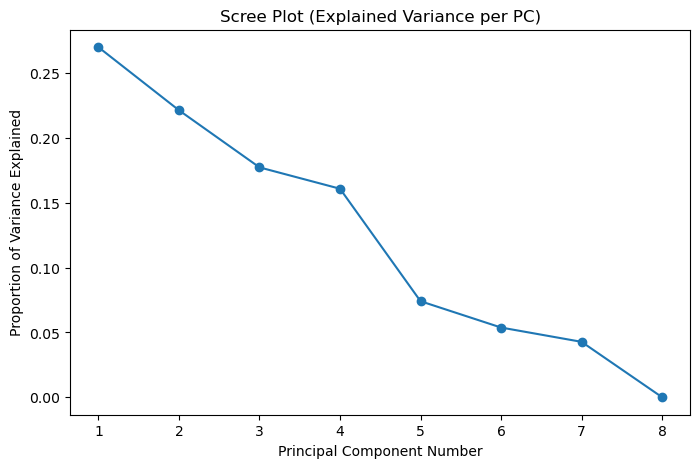

In [36]:
import matplotlib.pyplot as plt

# Plot explained variance ratio
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o')
plt.title('Scree Plot (Explained Variance per PC)')
plt.xlabel('Principal Component Number')
plt.ylabel('Proportion of Variance Explained')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.grid(False)
plt.show()

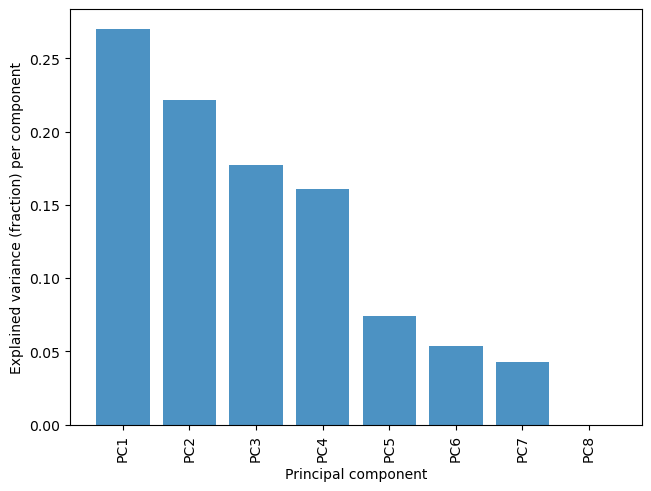

In [37]:
from psynlig import pca_explained_variance_bar
pca_explained_variance_bar(pca, alpha=0.8)

plt.show()

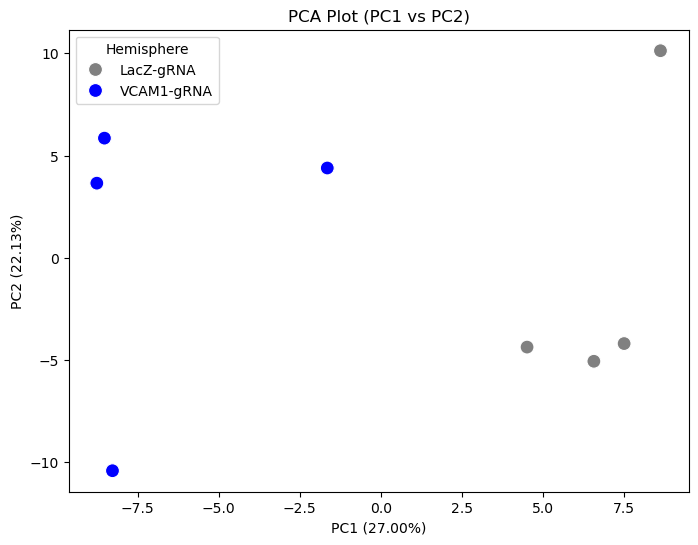

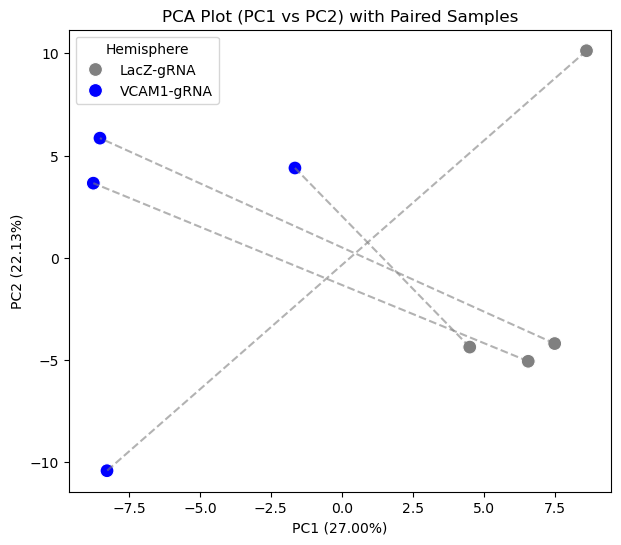

In [38]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Hemisphere', data=pc_df_with_metadata, s=100,
                palette={'LacZ-gRNA': 'grey', 'VCAM1-gRNA': 'blue'})
plt.title('PCA Plot (PC1 vs PC2)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(False)
plt.show()

# If you want to connect paired samples:
plt.figure(figsize=(7, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Hemisphere', data=pc_df_with_metadata, s=100,
                palette={'LacZ-gRNA': 'grey', 'VCAM1-gRNA': 'blue'}, legend='full')
for pair_id in pc_df_with_metadata['Brain'].unique():
    pair_data = pc_df_with_metadata[pc_df_with_metadata['Brain'] == pair_id]
    if len(pair_data) == 2: # Ensure both WT and KO of the pair are present
        plt.plot(pair_data['PC1'], pair_data['PC2'], color='gray', linestyle='--', alpha=0.6)
plt.title('PCA Plot (PC1 vs PC2) with Paired Samples')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(False)
plt.show()

In [ ]:
pc_df.head(10)

In [ ]:
vcam1_residuals_df.head(10)

In [ ]:
#### Pearson's correlation between metrics and PCs

from scipy.stats import pearsonr

feature_pc_correlations = pd.DataFrame(index=vcam1_residuals_df.columns, columns=pc_df.columns)
feature_pc_pvalues = pd.DataFrame(index=vcam1_residuals_df.columns, columns=pc_df.columns)


for feature in vcam1_residuals_df.columns:
    for pc_col in pc_df.columns:
        # Use pearsonr from scipy.stats which returns (correlation, p_value)
        # Check if there's enough variation to calculate correlation
        if vcam1_residuals_df[feature].nunique() > 1 and pc_df[pc_col].nunique() > 1:
            corr_val, p_val = pearsonr(vcam1_residuals_df[feature], pc_df[pc_col])
            feature_pc_correlations.loc[feature, pc_col] = corr_val
            feature_pc_pvalues.loc[feature, pc_col] = p_val
        else:
            # Assign NaN if correlation cannot be calculated (e.g., no variance)
            feature_pc_correlations.loc[feature, pc_col] = np.nan
            feature_pc_pvalues.loc[feature, pc_col] = np.nan

feature_pc_correlations = feature_pc_correlations.astype(float)
feature_pc_pvalues = feature_pc_pvalues.astype(float)

feature_pc_correlations = feature_pc_correlations.drop(columns=["PC5", "PC6", "PC7", "PC8"])

feature_pc_pvalues = feature_pc_pvalues.drop(columns=["PC5", "PC6", "PC7", "PC8"])

In [ ]:
feature_pc_correlations

In [ ]:
feature_pc_pvalues

In [ ]:
n_components_to_consider = 4

n_features = 192

pcs_for_sorting = ["PC1", "PC2", "PC3", "PC4"]

feature_pc_correlations['Abs_Sum'] = feature_pc_correlations.loc[:, pcs_for_sorting].abs().sum(axis=1)

sorted_features_by_custom_sum = feature_pc_correlations.sort_values(by='Abs_Sum', ascending=False).index

feature_pc_correlations = feature_pc_correlations.drop(columns=['Abs_Sum'])


feature_pc_correlations_sorted = feature_pc_correlations.loc[sorted_features_by_custom_sum]
feature_pc_pvalues_sorted = feature_pc_pvalues.loc[sorted_features_by_custom_sum]

alpha_level_1 = 0.05
alpha_level_2 = 0.01

annotation_matrix = feature_pc_pvalues_sorted.applymap(
    lambda x: '**' if x < alpha_level_2 else ('*' if x < alpha_level_1 else '')
)

# Add these lines BEFORE the sns.heatmap call
print(f"Shape of feature_pc_correlations_sorted: {feature_pc_correlations_sorted.shape}")
print(f"Shape of feature_pc_pvalues_sorted: {feature_pc_pvalues_sorted.shape}") # This is the source for annotation_matrix
print(f"Shape of annotation_matrix: {annotation_matrix.shape}") # To confirm annotation_matrix also has same shape

# Check if indices and columns are identical
print(f"Correlations sorted features (index) match P-values sorted features (index): {all(feature_pc_correlations_sorted.index == feature_pc_pvalues_sorted.index)}")
print(f"Correlations sorted PCs (columns) match P-values sorted PCs (columns): {all(feature_pc_correlations_sorted.columns == feature_pc_pvalues_sorted.columns)}")


plt.figure(figsize=(6 + n_components_to_consider * 0.8, n_features * 0.1))
sns.heatmap(feature_pc_correlations_sorted, cmap='coolwarm', center=0,
            linewidths=0.1, linecolor='lightgrey',
            cbar_kws={'label': 'Pearson Correlation Coefficient'},
            annot=annotation_matrix, fmt='', # Use empty format string to just show the '*' or '**'
            annot_kws={"size": 10, "color": "black"}) # Adjust annotation font size/color
plt.title(f'Pearson Correlation between Original Features and Top {n_components_to_consider} PCs\n'
          f'(Features Sorted by Absolute Sum of Correlations with {", ".join(pcs_for_sorting)})'
          f'\nSignificance: * p < {alpha_level_1}, ** p < {alpha_level_2}')
plt.xlabel('Principal Component')
plt.ylabel('Original Feature')
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

In [ ]:
feature_pc_correlations_sorted

In [ ]:
g = sns.clustermap(
    feature_pc_correlations_sorted,
    row_cluster=True,
    col_cluster=False,
    cmap='RdBu_r',
    center=0,
    annot=False,  # Manual annotation comes next
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': 'Correlation between features & PCs'},
    figsize=(10, 25)
)

g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=4)
ax = g.ax_heatmap
ax.set_yticks(np.arange(len(g.data2d.index)) + 0.5)
ax.set_yticklabels(g.data2d.index, fontsize=8)  # Set desired font size

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=9, rotation=0)

for i, feature in enumerate(g.data2d.index):
    for j, pc in enumerate(g.data2d.columns):
        text = annotation_matrix.loc[feature, pc]
        if text:  # Only annotate if there's something to show (not NaN or empty)
            g.ax_heatmap.text(j + 0.5, i + 0.5, text,
                              ha='center', va='center',
                              color='black', fontsize=10)

plt.show()


In [ ]:
feature_pc_pvalues.head(10)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Let's assume df is your DataFrame already loaded
# Group label from index
feature_pc_pvalues['group'] = feature_pc_pvalues.index.to_series().apply(
    lambda x: 'VGLUT1-PSD95' if 'VGLUT1.PSD95' in x else 'VGAT-GEPH'
)

# Create mask for significance
signif_mask = feature_pc_pvalues.drop(columns='group') < 0.05

# Count significant hits per group per PC
grouped = feature_pc_pvalues[['group']].join(signif_mask)

# Count how many significant values each group has per PC
result = grouped.groupby('group').sum()

# Normalize to get percentage per PC
percentages = result.div(result.sum(axis=0), axis=1) * 100
percentages = percentages.T  # Transpose so PCs are rows

ordered_groups = ['VGLUT1-PSD95', 'VGAT-GEPH']
custom_colors = {
    'VGLUT1-PSD95': '#a1c9f4',  
    'VGAT-GEPH': '#ffb482' 
}
percentages = percentages[ordered_groups]

# plot
fig, ax = plt.subplots(figsize=(4, 4))  # smaller figure width
percentages.plot(
    kind='bar', 
    stacked=True, 
    color=[custom_colors[col] for col in percentages.columns],
    width = 0.9,
    ax = ax
)

plt.ylabel('Percentage of significant values')
plt.title('Synapse type contribution per PC')
plt.xticks(rotation=0)
plt.ylim(0, 100)

ax.legend(
    title='Synapse type',
    loc='center left',
    bbox_to_anchor=(1.05, 0.8),  # position beside the plot
    borderaxespad=0,
    fontsize = 8,
    title_fontsize=9 
)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Group label from index
feature_pc_pvalues['group'] = feature_pc_pvalues.index.to_series().apply(
    lambda x: 'CA1' if 'CA1' in x else 'CA3' if 'CA3' in x else 'DG' if 'DG' in x else None
)

# Create mask for significance
signif_mask = feature_pc_pvalues.drop(columns='group') < 0.05

# Count significant hits per group per PC
grouped = feature_pc_pvalues[['group']].join(signif_mask)

# Count how many significant values each group has per PC
result = grouped.groupby('group').sum()

# Normalize to get percentage per PC
percentages = result.div(result.sum(axis=0), axis=1) * 100
percentages = percentages.T  # Transpose so PCs are rows

ordered_groups = ["CA1", "CA3", "DG"]
custom_colors = {
    'CA1': '#8ce5a1',  
    'CA3': '#ff9f9b' ,
    "DG" : "#cfbbff"
}
percentages = percentages[ordered_groups]

# plot
fig, ax = plt.subplots(figsize=(3.5, 4))  # smaller figure width
percentages.plot(
    kind='bar', 
    stacked=True, 
    color=[custom_colors[col] for col in percentages.columns],
    width = 0.9,
    ax = ax
)

plt.ylabel('Percentage of significant values')
plt.title('Region contribution per PC')
plt.xticks(rotation=0)
plt.ylim(0, 100)

ax.legend(
    title='Region',
    loc='center left',
    bbox_to_anchor=(1.05, 0.8),  # position beside the plot
    borderaxespad=0,
    fontsize = 8,
    title_fontsize=9 
)

plt.tight_layout()
plt.show()

In [ ]:
feature_pc_correlations_sorted

In [ ]:
##### Pearsons correlation between metrics
from psynlig import plot_correlation_heatmap

kwargs = {
    'text': {
        'fontsize': 'small',
    },
    'heatmap': {
        'vmin': -1,
        'vmax': 1,
        'cmap': 'magma',
    },
    'figure': {'figsize': (100, 100)},
}

plot_correlation_heatmap(vcam1_residuals_df, textcolors=['white', 'black'], **kwargs)
plt.show()

In [ ]:
#### PCA loadings

loadings_matrix = pca.components_
loadings_df = pd.DataFrame(loadings_matrix.T,
                           index=vcam1_residuals_df.columns,
                           columns=[f'PC{i+1}' for i in range(pca.n_components_)])

loadings_df

In [ ]:
loadings_df = loadings_df.rename_axis('feature').reset_index()

In [ ]:
# Remove prefix and split
loadings_df['clean_feature'] = loadings_df['feature'].str.replace('residual_', '', regex=False)
loadings_df[['synapse', 'layer', 'metric']] = loadings_df['clean_feature'].str.extract(r'([^_]+)_([^_]+)_([^_]+.*)')
loadings_df['region'] = loadings_df['layer'].str.extract(r'^(CA1|CA3|DG)')


In [ ]:
loadings_df.head(10)

In [ ]:
# calculating sum of squared loadings (to get positive values)
# For synapse type
synapse_contrib = loadings_df.groupby('synapse')[['PC1', 'PC2']].apply(lambda x: (x**2).sum())

# For region
region_contrib = loadings_df.groupby('region')[['PC1', 'PC2']].apply(lambda x: (x**2).sum())

# For hippocampal layer
layer_contrib = loadings_df.groupby('layer')[['PC1', 'PC2']].apply(lambda x: (x**2).sum())

# normalize by total variance in each PC to get percentage wise contributions
synapse_contrib_norm = synapse_contrib.div(synapse_contrib.sum()) * 100
region_contrib_norm = region_contrib.div(region_contrib.sum()) * 100
layer_contrib_norm = layer_contrib.div(layer_contrib.sum()) * 100


In [ ]:
# Plot for synapse type contributions

synapse_contrib_norm_t = synapse_contrib_norm.T  # transpose so PCs are rows

synapse_contrib_norm_t = synapse_contrib_norm_t.rename(columns={"VGAT.GEPH": "VGAT-GEPH", "VGLUT1.PSD95": "VGLUT1-PSD95"})

ordered_groups = ['VGLUT1-PSD95', 'VGAT-GEPH']
custom_colors = {
    'VGLUT1-PSD95': '#a1c9f4',  
    'VGAT-GEPH': '#ffb482' 
}
synapse_contrib_norm_t = synapse_contrib_norm_t[ordered_groups]

# plot
fig, ax = plt.subplots(figsize=(3, 4))  # smaller figure width
synapse_contrib_norm_t.plot(
    kind='bar', 
    stacked=True, 
    color=[custom_colors[col] for col in synapse_contrib_norm_t.columns],
    width = 0.9,
    ax = ax
)

plt.ylabel('Normalized contribution')
plt.title('Synapse type contribution per PC')
plt.xticks(rotation=0)
plt.ylim(0, 100)

ax.legend(
    title='Synapse type',
    loc='center left',
    bbox_to_anchor=(1.05, 0.8),  # position beside the plot
    borderaxespad=0,
    fontsize = 8,
    title_fontsize=9 
)

plt.tight_layout()
plt.show()

In [ ]:
# Plot for layer contributions

layer_contrib_norm_t = layer_contrib_norm.T  # transpose so PCs are rows

layer_contrib_norm_t = layer_contrib_norm_t.rename(
    columns={
        "CA1.SO": "CA1-SO", 
        "CA1.SR": "CA1-SR",
        "CA1.SLM": "CA1-SLM",
        "CA3.SO": "CA3-SO",
        "CA3.SL": "CA3-SL",
        "CA3.SR": "CA3-SR",
        "DG.ML": "DG-ML",
        "DG.Hilus": "DG-Hilus",
    }
)

ordered_groups = [
    "CA1-SO", 
    "CA1-SR",
    "CA1-SLM",
    "CA3-SO",
    "CA3-SL",
    "CA3-SR",
    "DG-ML",
    "DG-Hilus"
]


layer_contrib_norm_t = layer_contrib_norm_t[ordered_groups]

# plot
fig, ax = plt.subplots(figsize=(3, 4))  # smaller figure width
layer_contrib_norm_t.plot(
    kind='bar', 
    stacked=True, 
    color=sns.color_palette(palette='Accent'),
    width = 0.9,
    ax = ax
)

plt.ylabel('Normalized contribution')
plt.title('Hippocampal layer contribution per PC')
plt.xticks(rotation=0)
plt.ylim(0, 100)

ax.legend(
    title='Hippocampal layer',
    loc='center left',
    bbox_to_anchor=(1.05, 0.8),  # position beside the plot
    borderaxespad=0,
    fontsize = 8,
    title_fontsize=9 
)

plt.tight_layout()
plt.show()

In [ ]:
explained_var_full = pca.explained_variance_ratio_[:2]
explained_var_full

In [ ]:
explained_var_full

In [ ]:
synapse_overall_contrib = (synapse_contrib * explained_var_full).sum(axis=1)
synapse_overall_contrib

synapse_overall_contrib_norm = synapse_overall_contrib / synapse_overall_contrib.sum()

synapse_overall_contrib_norm.sort_values().plot(kind='barh', title="Overall synapse type contributions (Weighted)")
plt.xlabel("Normalized Contribution to Total Variance")
plt.show()

In [ ]:
layer_overall_contrib = (layer_contrib * explained_var_full).sum(axis=1)
layer_overall_contrib

layer_overall_contrib_norm = layer_overall_contrib / layer_overall_contrib.sum()


layer_overall_contrib_norm.sort_values().plot(kind='barh', title="Overall hippocampal layer contributions (Weighted)")
plt.xlabel("Normalized Contribution to Total Variance")
plt.show()

In [ ]:
# Sort features by their absolute loading on PC1
top_pc1_features = loadings_df['PC1'].abs().sort_values(ascending=False)
print("\nTop 10 features contributing to PC1:")
print(top_pc1_features.head(10))

# Get the actual loading values for these top features
print("\nTop 10 PC1 features with their loading values:")
print(loadings_df.loc[top_pc1_features.head(10).index, 'PC1'])


# Sort features by their absolute loading on PC2
top_pc2_features = loadings_df['PC2'].abs().sort_values(ascending=False)
print("\nTop 10 features contributing to PC2:")
print(top_pc2_features.head(10))

In [ ]:
loadings_df['Abs_PC_Contribution'] = loadings_df[["PC1", "PC2", "PC3", "PC4"]].abs().sum(axis=1) # Sum of absolute loadings for PC1 and PC2

In [ ]:
top_n_features_for_heatmap = 25 # You want the top 20
top_features_loadings = loadings_df.sort_values(by='Abs_PC_Contribution', ascending=False).head(top_n_features_for_heatmap)


In [ ]:
heatmap_loadings_data = top_features_loadings.drop(columns=[ "PC5", "PC6", "PC7", "PC8"])

print(f"\nHeatmap data (loadings for top {top_n_features_for_heatmap} features):")
print(heatmap_loadings_data)

# --- Create the Heatmap of Loadings ---
plt.figure(figsize=(10, 10)) # Adjust figure size for better readability

sns.heatmap(
    heatmap_loadings_data,
    cmap='RdBu_r', # Red-Blue diverging colormap (red for positive, blue for negative)
                   # 'vlag' is another good diverging option
    center=0,      # Ensure 0 is the white/neutral color
    annot=False,    # Show numerical values in cells (can make it crowded if too many features)
    fmt=".2f",     # Format annotation to 2 decimal places
    linewidths=.5, # Add lines between cells
    cbar_kws={'label': 'PCA Loading'} # Label for the color bar
)

plt.title(f'PCA Loadings Heatmap (Top {top_n_features_for_heatmap} Features)')
# plt.title(f'PCA Loadings Heatmap all Features')
plt.xlabel('Principal Component')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10, 10))
sns.clustermap(
    heatmap_loadings_data,
    row_cluster=True,  # Cluster features (rows)
    col_cluster=False, # Do not cluster PCs (columns) - keep them in order PC1, PC2, etc.
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'PCA Loading'},
    figsize=(10, 12) # Adjust size
)
plt.suptitle(f'Clustered PCA Loadings Heatmap (Top {top_n_features_for_heatmap} Features)', y=1.02, fontsize=16)
plt.show()

In [ ]:
# Ranking the vcam1 residuals according to the absolute mean

scaled_vcam1_residuals_df['gRNA'] = [idx.split('_')[0] for idx in scaled_vcam1_residuals_df.index]
mean_per_group = scaled_vcam1_residuals_df.groupby('gRNA').mean()

group1_mean = mean_per_group.loc['LacZ-gRNA']
group2_mean = mean_per_group.loc['VCAM1-gRNA']

difference_values = group1_mean - group2_mean
absolute_difference_values = difference_values.abs()

ranked_features = absolute_difference_values.sort_values(ascending=False)
ranked_features_df = pd.DataFrame({
    'Absolute_Mean_Difference': ranked_features
})

ranked_features_df = ranked_features_df.reset_index()
ranked_features_df = ranked_features_df.rename(columns={'index': 'Feature'})


ordered_feature_columns = ranked_features_df['Feature'].tolist()
scaled_vcam1_residuals_df_ranked = scaled_vcam1_residuals_df[ordered_feature_columns + ['gRNA']].copy()


In [ ]:
scaled_vcam1_residuals_df_ranked

In [ ]:
# take the top 30 ranked metrics 
top_N = 25
scaled_vcam1_residuals_df_ranked_top = scaled_vcam1_residuals_df_ranked.iloc[:, :top_N]
scaled_vcam1_residuals_df_ranked_top

In [ ]:
scaled_vcam1_residuals_df

In [ ]:
#### Heatmap of samples x 192 metrics

heatmap_data = scaled_vcam1_residuals_df_ranked_top#.drop("gRNA", axis= 1)

sample_hemispheres = [idx.split('_')[0] for idx in heatmap_data.index]
sample_brain_ids = [idx.split('_')[1] for idx in heatmap_data.index] # This will be 'Brain-4', 'Brain-4-2', etc.

# Create color mappings
# For Hemisphere
hemisphere_color_map = {'LacZ-gRNA': 'lightgrey', 'VCAM1-gRNA': 'skyblue'}
row_colors_hemisphere = [hemisphere_color_map[h] for h in sample_hemispheres]

# For BrainID (you have 'Brain-4', 'Brain-4-2', 'Brain-5', 'Brain-7')
unique_brain_ids = sorted(list(set(sample_brain_ids)))
brain_palette = sns.color_palette("Set3", len(unique_brain_ids))
brain_color_map = {brain_id_str: brain_palette[i] for i, brain_id_str in enumerate(unique_brain_ids)}
row_colors_brain = [brain_color_map[b] for b in sample_brain_ids]

# Combine into a DataFrame for clustermap's row_colors
row_colors_df = pd.DataFrame({
    'Hemisphere': row_colors_hemisphere,
    'BrainID': row_colors_brain
}, index=heatmap_data.index)


# --- Create the Heatmap ---


plt.figure(figsize=(12, 20)) # Adjust size as needed

g = sns.clustermap(
        heatmap_data,
        method='weighted',      # Linkage method for clustering rows/columns
        metric='euclidean', # Distance metric for clustering
        cmap='vlag',        # Colormap for diverging data (e.g., values around 0)
        row_colors=row_colors_df, # Annotate rows with colors for Hemisphere and BrainID
        col_cluster=True,   # Cluster columns (features)
        row_cluster=True,   # Cluster rows (samples)
        dendrogram_ratio=(.05, .2), # Adjust dendrogram size
        cbar_pos=(.95, .8, .02, .18), # Position of the color bar [left, bottom, width, height]
        # annot = True,
        # annot_kws={"size": 5},
        figsize=(7, 10) # Overall figure size
)


plt.suptitle('Heatmap of Brain-Adjusted Features', y=1.02, fontsize=16) # Title for the figure
plt.show()

In [ ]:
# PCA on residuals of metrics
vcam1_residuals = "/Volumes/Intenso/image-analysis/synapse-counting/VCAM1/vcam1_lmem_residuals_results.csv"
vcam1_residuals_df = pd.read_csv(vcam1_residuals, index_col=0)
vcam1_residuals_df.rename_axis("sample_ID")

In [ ]:
vcam1_residuals_df_metrics = vcam1_residuals_df.T
vcam1_residuals_df_metrics

In [ ]:
vcam1_residuals_df_metrics_gRNA = vcam1_residuals_df_metrics[["LacZ-gRNA_Brain-4", "LacZ-gRNA_Brain-4-2", "LacZ-gRNA_Brain-5", "LacZ-gRNA_Brain-7"]]
vcam1_residuals_df_metrics_gRNA

In [ ]:
import pandas as pd
import re

def parse_rowname(rowname):
    """
    Parse a rowname string to extract layer, synapse_type, and region information.
    
    Expected format: residual_SYNAPSE_TYPE_LAYER_[additional_suffixes]
    Where SYNAPSE_TYPE contains dots (e.g., VGAT.GEPH) and LAYER contains dots (e.g., CA1.SLM)
    """
    # Remove the prefix "residual_"
    if rowname.startswith('residual_'):
        cleaned = rowname[9:]  # Remove "residual_"
    else:
        cleaned = rowname
    
    # Split by underscore
    parts = cleaned.split('_')
    
    if len(parts) >= 2:
        synapse_type = parts[0]  # e.g., "VGAT.GEPH"
        
        # The layer should be the second part (parts[1])
        # It should contain a dot (e.g., CA1.SLM, DG.ML, etc.)
        layer = parts[1]
        
        # Extract region (first part before the dot in layer)
        region = layer.split('.')[0] if '.' in layer else layer
        
        return {
            'layer': layer,
            'synapse_type': synapse_type,
            'region': region
        }
    else:
        return {
            'layer': None,
            'synapse_type': None,
            'region': None
        }

# Example usage with different suffixes
test_strings = [
    "residual_VGAT.GEPH_CA1.SLM_local_peak_colocalized_spots",
    "residual_VGAT.GEPH_CA1.SLM_post_mean_puncta_size_um2",
    "residual_VGLUT1.PSD95_CA1.SO_local_peak_colocalized_spots",
    "residual_GABA.HOMER_DG.ML_post_mean_puncta_size_um2"
]

for test_string in test_strings:
    result = parse_rowname(test_string)
    print(f"Original: {test_string}")
    print(f"  Layer: {result['layer']}")
    print(f"  Synapse type: {result['synapse_type']}")
    print(f"  Region: {result['region']}")
    print()

# If you have a DataFrame with index containing these strings
sample_index = [
    "residual_VGAT.GEPH_CA1.SLM_local_peak_colocalized_spots",
    "residual_VGLUT1.PSD95_CA1.SO_local_peak_colocalized_spots", 
    "residual_GABA.HOMER_DG.ML_local_peak_colocalized_spots"
]

# Create DataFrame with these as index
df = pd.DataFrame({'value': [1, 2, 3]}, index=sample_index)

# Apply parsing function to the index
parsed_data = pd.Series(df.index).apply(parse_rowname)
df_parsed = pd.json_normalize(parsed_data)

# Set the same index for the parsed data
df_parsed.index = df.index

# Combine with original data
result_df = pd.concat([df, df_parsed], axis=1)
print("\nDataFrame result:")
print(result_df)

# Alternative: Reset index to make it a column, parse, then set new columns
df_reset = df.reset_index()
df_reset.rename(columns={'index': 'original_index'}, inplace=True)
parsed_data = df_reset['original_index'].apply(parse_rowname)
df_parsed = pd.json_normalize(parsed_data)
result_df_alt = pd.concat([df_reset, df_parsed], axis=1)
print("\nAlternative approach (index as column):")
print(result_df_alt)

In [ ]:
df = vcam1_residuals_df_metrics_gRNA
# Apply parsing function to the index
parsed_data = pd.Series(df.index).apply(parse_rowname)
df_parsed = pd.json_normalize(parsed_data)

# Set the same index for the parsed data
df_parsed.index = df.index

# Combine with original data
result_df = pd.concat([df, df_parsed], axis=1)
print("\nDataFrame result:")
print(result_df)

# Alternative: Reset index to make it a column, parse, then set new columns
df_reset = df.reset_index()
df_reset.rename(columns={'index': 'original_index'}, inplace=True)
parsed_data = df_reset['original_index'].apply(parse_rowname)
df_parsed = pd.json_normalize(parsed_data)
result_df_alt = pd.concat([df_reset, df_parsed], axis=1)
print("\nAlternative approach (index as column):")
result_df_alt

In [ ]:
metadata = result_df_alt[["original_index", "layer", "synapse_type", "region"]]
metadata = metadata.rename(columns={"original_index" : "metric_ID" })
metadata = metadata.set_index("metric_ID")
metadata

In [ ]:
# PCA analysis
scaler = StandardScaler()
scaled_vcam1_residuals_metrics = scaler.fit_transform(vcam1_residuals_df_metrics_gRNA)

pca = PCA()
principal_components = pca.fit_transform(scaled_vcam1_residuals_metrics)

print(principal_components)

In [ ]:
import matplotlib.pyplot as plt

# Plot explained variance ratio
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o')
plt.title('Scree Plot (Explained Variance per PC)')
plt.xlabel('Principal Component Number')
plt.ylabel('Proportion of Variance Explained')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.grid(False)
plt.show()

In [ ]:
pc_df = pd.DataFrame(data=principal_components,
                     columns=[f'PC{i+1}' for i in range(principal_components.shape[1])],
                     index=vcam1_residuals_df_metrics.index)
pc_df = pc_df.rename_axis("metric_ID")
pc_df

In [ ]:
pc_df_with_metadata = pd.merge(pc_df, metadata, on = "metric_ID", how = "outer")
pc_df_with_metadata

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='synapse_type', data=pc_df_with_metadata, s=100)
plt.title('PCA Plot (PC1 vs PC2)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(False)
plt.show()

# # If you want to connect paired samples:
# plt.figure(figsize=(7, 6))
# sns.scatterplot(x='PC1', y='PC2', hue='Hemisphere', data=pc_df_with_metadata, s=100,
#                 palette={'LacZ-gRNA': 'grey', 'VCAM1-gRNA': 'blue'}, legend='full')
# for pair_id in pc_df_with_metadata['Brain'].unique():
#     pair_data = pc_df_with_metadata[pc_df_with_metadata['Brain'] == pair_id]
#     if len(pair_data) == 2: # Ensure both WT and KO of the pair are present
#         plt.plot(pair_data['PC1'], pair_data['PC2'], color='gray', linestyle='--', alpha=0.6)
# plt.title('PCA Plot (PC1 vs PC2) with Paired Samples')
# plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
# plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
# plt.grid(False)
# plt.show()

In [ ]:
# UMAP on residuals of metrics